# EDA — Подбор параметров лекарственных препаратов

**Целевые переменные:**
- IC50, mM — полумаксимальная ингибирующая концентрация (чем ниже — тем активнее соединение)
- CC50, mM — цитотоксическая концентрация 50% (чем выше — тем безопаснее)
- SI — индекс селективности: SI = CC50 / IC50 (чем выше — тем лучше соединение)

**Задачи моделирования:**
- Регрессия для IC50
- Регрессия для CC50
- Регрессия для SI
- Классификация: превышает ли значение IC50 медианное значение выборки 
- Классификация: превышает ли значение CC50 медианное значение выборки
- Классификация: превышает ли значение SI медианное значение выборки
- Классификация: превышает ли значение SI значение 8

In [72]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

TARGET_COLS = ['IC50, mM', 'CC50, mM', 'SI']

In [73]:
def save_dataset(dataset, filename):
    dataset.to_pickle(f'{filename}.pkl')

def load_dataset(filename):
    return pd.read_pickle(f'{filename}.pkl')

## Загрузка и первичный осмотр данных

In [74]:
df = pd.read_excel('SF_ML_data.xlsx', index_col=0)
print(f'Размерность датасета: {df.shape}')
print(f'Признаков (без таргетов): {df.shape[1] - len(TARGET_COLS)}')
print(f'Наблюдений: {df.shape[0]}')

Размерность датасета: (1001, 213)
Признаков (без таргетов): 210
Наблюдений: 1001


In [75]:
df.head(5)

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


Все данные представлены в числовой форме (float64 и int64)

In [77]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089176,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000
MaxAbsEStateIndex,1001.0,10.831637,3.307505,2.321942,9.252350,12.179236,13.167843,15.933463
MaxEStateIndex,1001.0,10.831637,3.307505,2.321942,9.252350,12.179236,13.167843,15.933463
...,...,...,...,...,...,...,...,...
fr_thiazole,1001.0,0.051948,0.222033,0.000000,0.000000,0.000000,0.000000,1.000000
fr_thiocyan,1001.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,1001.0,0.069930,0.255157,0.000000,0.000000,0.000000,0.000000,1.000000
fr_unbrch_alkane,1001.0,0.204795,1.215326,0.000000,0.000000,0.000000,0.000000,20.000000


## Анализ пропущенных значений

In [78]:
n_duplicates = df.duplicated().sum()

print(f"Количество полных дубликатов строк: {n_duplicates}")
print(f"Доля дубликатов: {n_duplicates / len(df) * 100:.2f}%")

Количество полных дубликатов строк: 32
Доля дубликатов: 3.20%


In [79]:
na_summary = pd.DataFrame({'count': df.isna().sum(), 'pct': (df.isna().mean() * 100).round(2)})
na_with_missing = na_summary[na_summary['count'] > 0].sort_values('count', ascending=False)

print(f'Столбцов с пропусками: {len(na_with_missing)}')
print('\nСтолбцы с пропусками:')
display(na_with_missing)

Столбцов с пропусками: 12

Столбцы с пропусками:


,count,pct
MaxPartialCharge,3,0.3
MinPartialCharge,3,0.3
MaxAbsPartialCharge,3,0.3
MinAbsPartialCharge,3,0.3
BCUT2D_MWHI,3,0.3
BCUT2D_MWLOW,3,0.3
BCUT2D_CHGHI,3,0.3
BCUT2D_CHGLO,3,0.3
BCUT2D_LOGPHI,3,0.3
BCUT2D_LOGPLOW,3,0.3


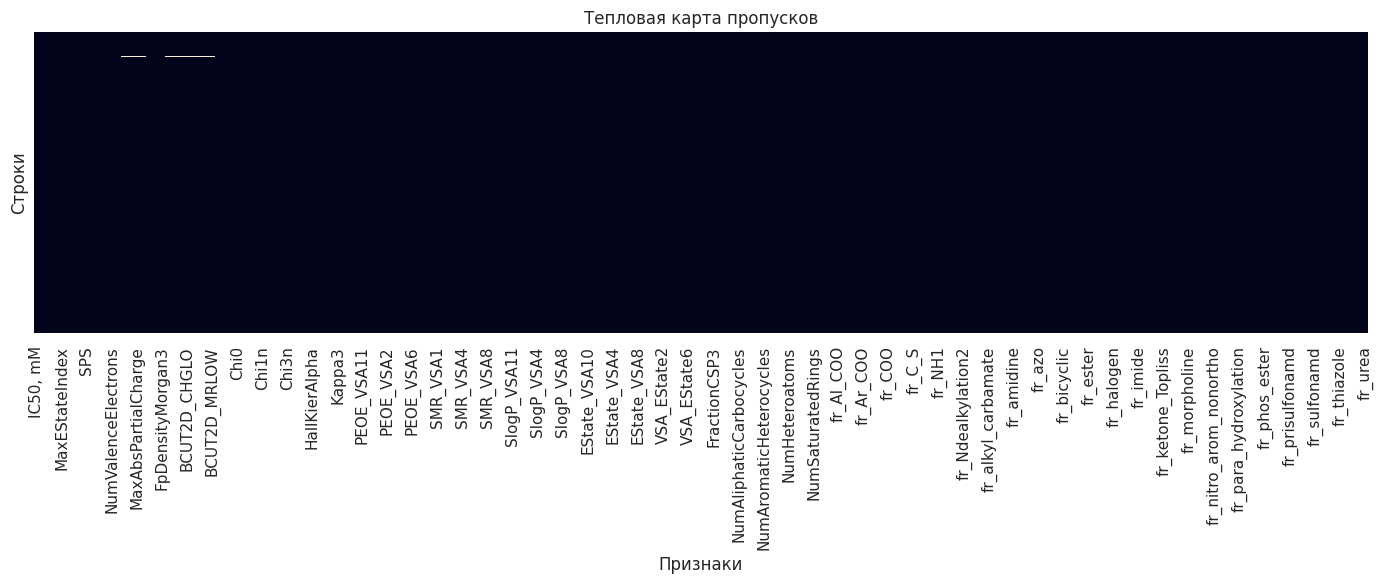

In [80]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title('Тепловая карта пропусков')
plt.xlabel('Признаки')
plt.ylabel('Строки')
plt.tight_layout()
plt.show()

In [81]:
df_no_dup  = df.drop_duplicates()
df_clear   = df_no_dup.dropna()

print(f'Исходно строк: {df.shape[0]}')
print(f'Удалено дубликатов: {df.shape[0] - df_no_dup.shape[0]}')
print(f'Удалено строк с пропусками: {df_no_dup.shape[0] - df_clear.shape[0]}')
print(f'Итого строк: {df_clear.shape[0]}')

Исходно строк: 1001
Удалено дубликатов: 32
Удалено строк с пропусками: 3
Итого строк: 966


In [82]:
save_dataset(df_clear, 'SF_ML_data_clear')

## Анализ целевых переменных

Так как распределения IC50, CC50 и SI напрямую влияют на выбор моделей, метрик и порогов классификации - проведём анализ целевых переменных.

### Анализ распределения целевых переменных (для задач регрессии)

In [83]:
target_stats = df_clear[TARGET_COLS].agg([
    'mean', 'median', 'std', 'min', 'max',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    lambda x: stats.skew(x),
    lambda x: stats.kurtosis(x)
]).T

target_stats.columns = ['mean', 'median', 'std', 'min', 'max', 'Q1', 'Q3', 'skewness', 'kurtosis']
target_stats = target_stats.round(4)

print('Статистика целевых переменных:')
display(target_stats)

Статистика целевых переменных:


,mean,median,std,min,max,Q1,Q3,skewness,kurtosis
"IC50, mM",218.9775,45.2228,395.4115,0.0035,4128.5294,12.4913,225.2270,3.7996,24.3248
"CC50, mM",583.8883,422.1588,632.6924,0.7008,4538.9762,99.9991,886.3893,2.0103,6.0522
SI,74.1183,3.9134,696.6371,0.0115,15620.6000,1.4944,16.3325,17.6733,347.0634


In [84]:
si_calc = df_clear["CC50, mM"] / df_clear["IC50, mM"]

si_diff = (df_clear["SI"] - si_calc).abs()

print("Максимальное расхождение SI:", si_diff.max())
print("Среднее расхождение SI:", si_diff.mean())
print("Количество строк с заметным расхождением:", (si_diff > 1e-6).sum())

Максимальное расхождение SI: 1.8189894035458565e-12
Среднее расхождение SI: 9.210273661179415e-15
Количество строк с заметным расхождением: 0


In [85]:
def plot_hist_box(data, color: str = 'steelblue', kde_color: str = 'darkblue'):
    fig = plt.figure(figsize=(7, 5))
    gs  = fig.add_gridspec(nrows=2, height_ratios=[4, 1], hspace=0.05)

    ax_hist = fig.add_subplot(gs[0])
    ax_box  = fig.add_subplot(gs[1], sharex=ax_hist)

    ax_hist.hist(data, bins=30, color=color, edgecolor='white', alpha=0.8, density=True)
    data.plot.kde(ax=ax_hist, color=kde_color, linewidth=2)
    ax_hist.axvline(data.median(), color='red',    linestyle='--', linewidth=1.5, label=f'Median={data.median():.3f}')
    ax_hist.axvline(data.mean(),   color='orange', linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.3f}')
    ax_hist.set_title(data.name)
    ax_hist.set_ylabel('Плотность')
    ax_hist.legend(fontsize=8)
    plt.setp(ax_hist.get_xticklabels(), visible=False)

    ax_box.boxplot(
        data, vert=False, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.4, linewidth=1.2),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=3, alpha=0.5, markeredgewidth=0.5)
    )
    ax_box.set_xlabel(data.name)
    ax_box.set_yticks([])

    plt.tight_layout()
    plt.show()

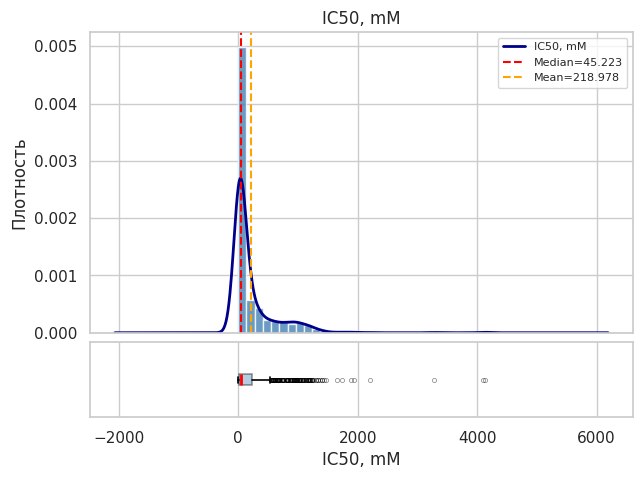

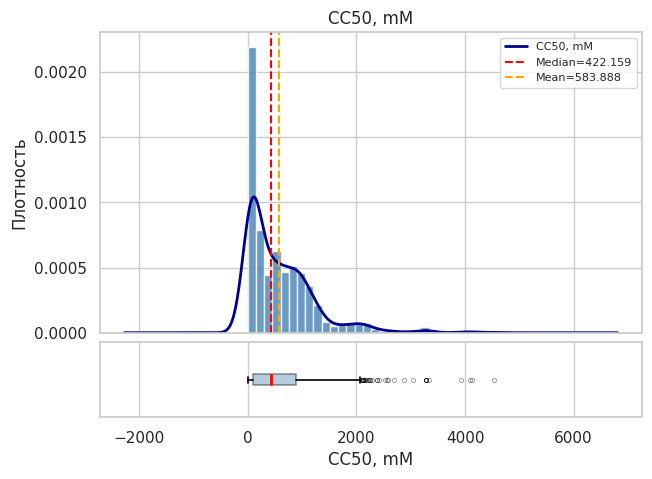

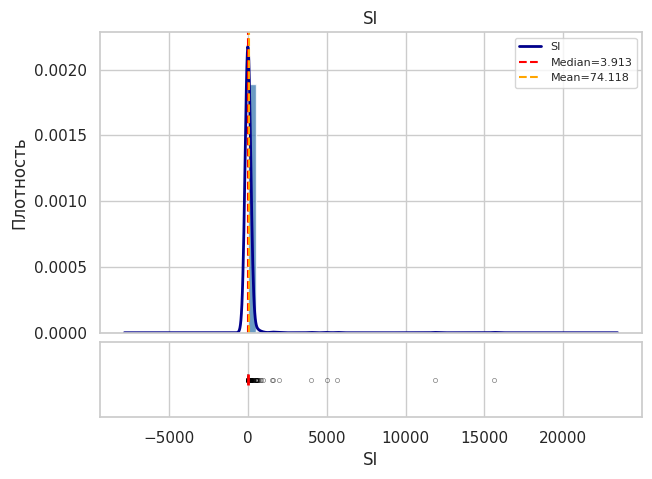

In [86]:
for col in TARGET_COLS:
    plot_hist_box(df_clear[col])

Так как распределение целевых переменных сильно скошено вправо, воспользуемся логарифмированием для улучшения нормальности.

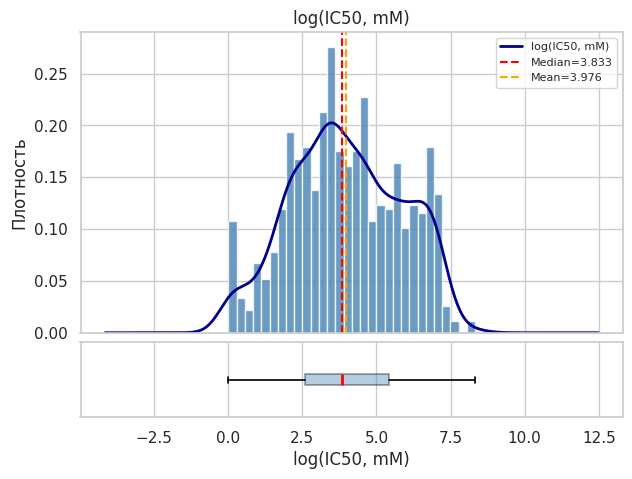

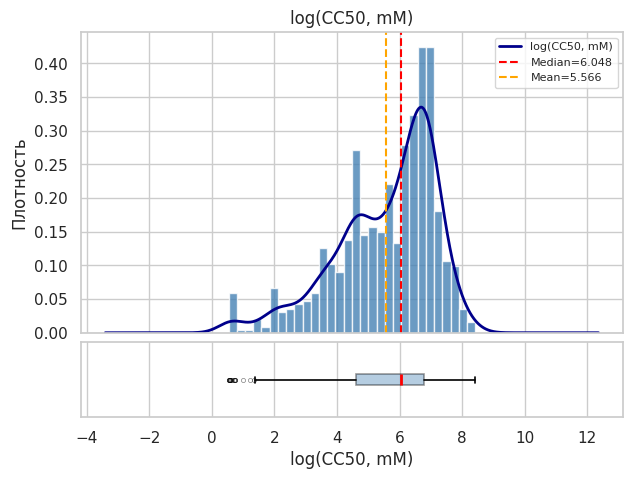

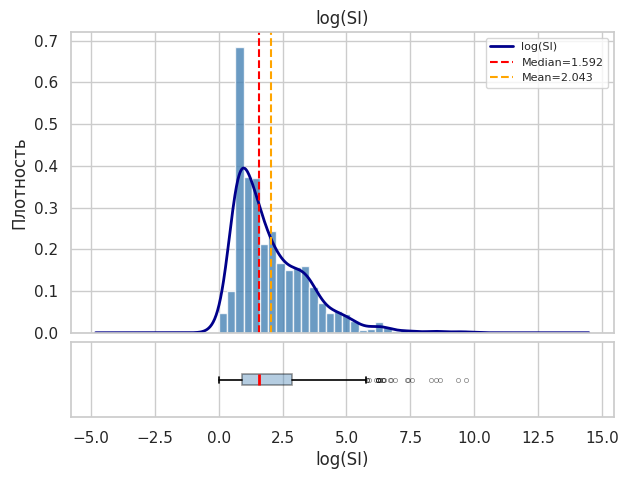

In [87]:
for col in TARGET_COLS:
    plot_hist_box(np.log1p(df_clear[col]).rename(f'log({col})'))

In [88]:
log_target_stats = pd.DataFrame({
    "target": TARGET_COLS,
    "skew_original": [stats.skew(df_clear[col]) for col in TARGET_COLS],
    "skew_log1p": [stats.skew(np.log1p(df_clear[col])) for col in TARGET_COLS],
    "kurtosis_original": [stats.kurtosis(df_clear[col]) for col in TARGET_COLS],
    "kurtosis_log1p": [stats.kurtosis(np.log1p(df_clear[col])) for col in TARGET_COLS],
})

display(log_target_stats.round(4))

,target,skew_original,skew_log1p,kurtosis_original,kurtosis_log1p
0,"IC50, mM",3.7996,-0.0209,24.3248,-0.7466
1,"CC50, mM",2.0103,-0.9384,6.0522,0.4909
2,SI,17.6733,1.4634,347.0634,2.8280


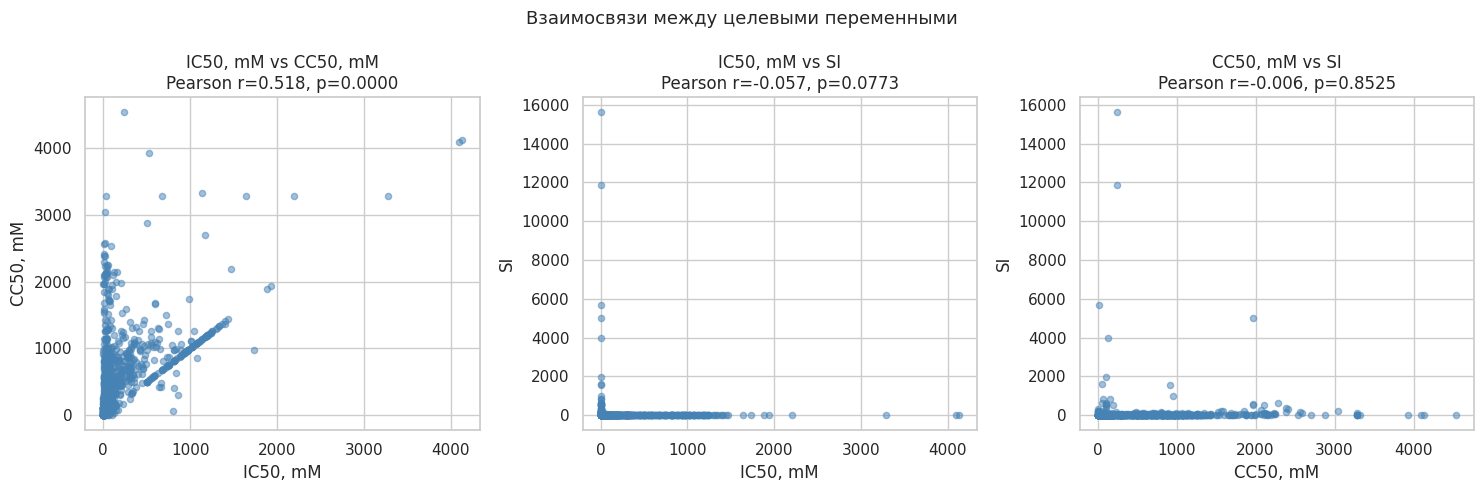

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [('IC50, mM', 'CC50, mM'), ('IC50, mM', 'SI'), ('CC50, mM', 'SI')]

for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(df_clear[x_col], df_clear[y_col], alpha=0.5, s=20, color='steelblue')
    r, p = stats.pearsonr(df_clear[x_col].dropna(), df_clear[y_col].dropna())
    ax.set_title(f'{x_col} vs {y_col}\nPearson r={r:.3f}, p={p:.4f}')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

plt.suptitle('Взаимосвязи между целевыми переменными', fontsize=13)
plt.tight_layout()
plt.show()

### Анализ баланса классов (для задач классификации)

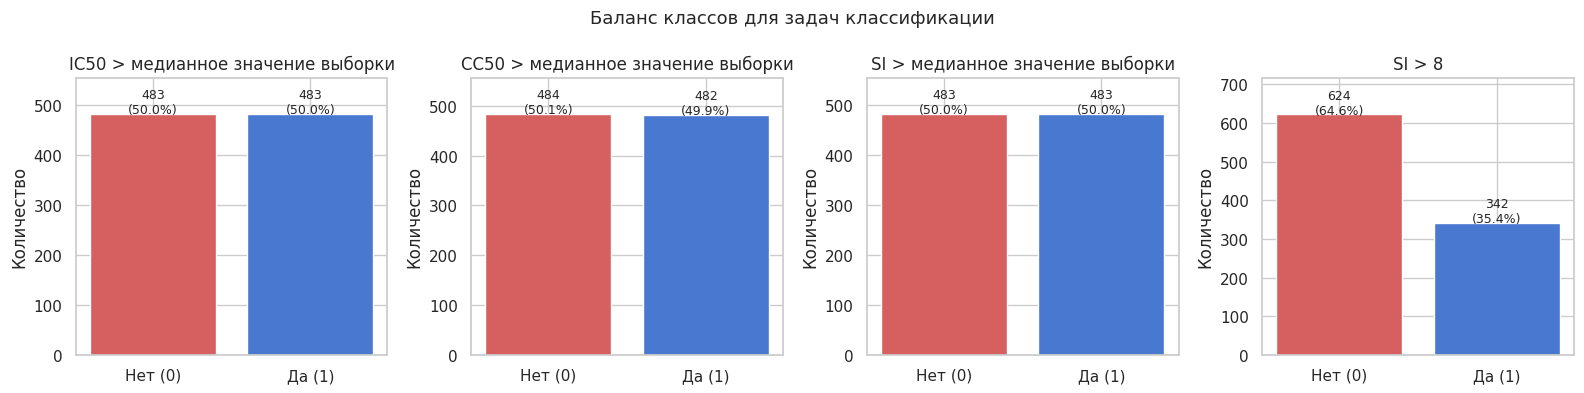


Медианы целевых переменных:
  IC50, mM: 45.2228
  CC50, mM: 422.1588
  SI: 3.9134

Доля SI > 8: 35.40%


In [90]:
palette = sns.color_palette('muted')

df_clear = df_clear.copy()

df_clear['y_ic50_gt_median'] = (df_clear['IC50, mM'] > df_clear['IC50, mM'].median()).astype(int)
df_clear['y_cc50_gt_median'] = (df_clear['CC50, mM'] > df_clear['CC50, mM'].median()).astype(int)
df_clear['y_si_gt_median']   = (df_clear['SI'] > df_clear['SI'].median()).astype(int)
df_clear['y_si_gt_8']        = (df_clear['SI'] > 8).astype(int)

clf_targets = {
    'IC50 > медианное значение выборки': 'y_ic50_gt_median',
    'CC50 > медианное значение выборки': 'y_cc50_gt_median',
    'SI > медианное значение выборки':   'y_si_gt_median',
    'SI > 8':        'y_si_gt_8'
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, col) in zip(axes, clf_targets.items()):
    vc = df_clear[col].value_counts().sort_index()
    ax.bar(['Нет (0)', 'Да (1)'], vc.values, color=[palette[3], palette[0]], edgecolor='white')
    for j, v in enumerate(vc.values):
        ax.text(j, v + 0.5, f'{v}\n({v/len(df_clear)*100:.1f}%)', ha='center', fontsize=9)
    ax.set_title(label)
    ax.set_ylabel('Количество')
    ax.set_ylim(0, vc.max() * 1.15)

plt.suptitle('Баланс классов для задач классификации', fontsize=13)
plt.tight_layout()
plt.show()

print('\nМедианы целевых переменных:')
for col in TARGET_COLS:
    print(f'  {col}: {df_clear[col].median():.4f}')
print(f'\nДоля SI > 8: {df_clear["y_si_gt_8"].mean():.2%}')

### Анализ выбросов в целевых переменных

In [91]:
def iqr_outlier_mask(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

print('Выбросы по IQR-правилу (целевые переменные):')
for col in TARGET_COLS:
    mask = iqr_outlier_mask(df_clear[col])
    print(f'  {col}: {mask.sum()} выбросов ({mask.mean()*100:.1f}%)')

Выбросы по IQR-правилу (целевые переменные):
  IC50, mM: 140 выбросов (14.5%)
  CC50, mM: 35 выбросов (3.6%)
  SI: 119 выбросов (12.3%)


In [92]:
print('Выбросы по z-score (|z| > 3):')
for col in TARGET_COLS:
    z = np.abs(stats.zscore(df_clear[col]))
    n_out = (z > 3).sum()
    print(f'  {col}: {n_out} выбросов ({n_out/len(df_clear)*100:.1f}%)')

Выбросы по z-score (|z| > 3):
  IC50, mM: 11 выбросов (1.1%)
  CC50, mM: 16 выбросов (1.7%)
  SI: 5 выбросов (0.5%)


## Анализ признакового пространства

### Корреляция признаков

Признаков: 210


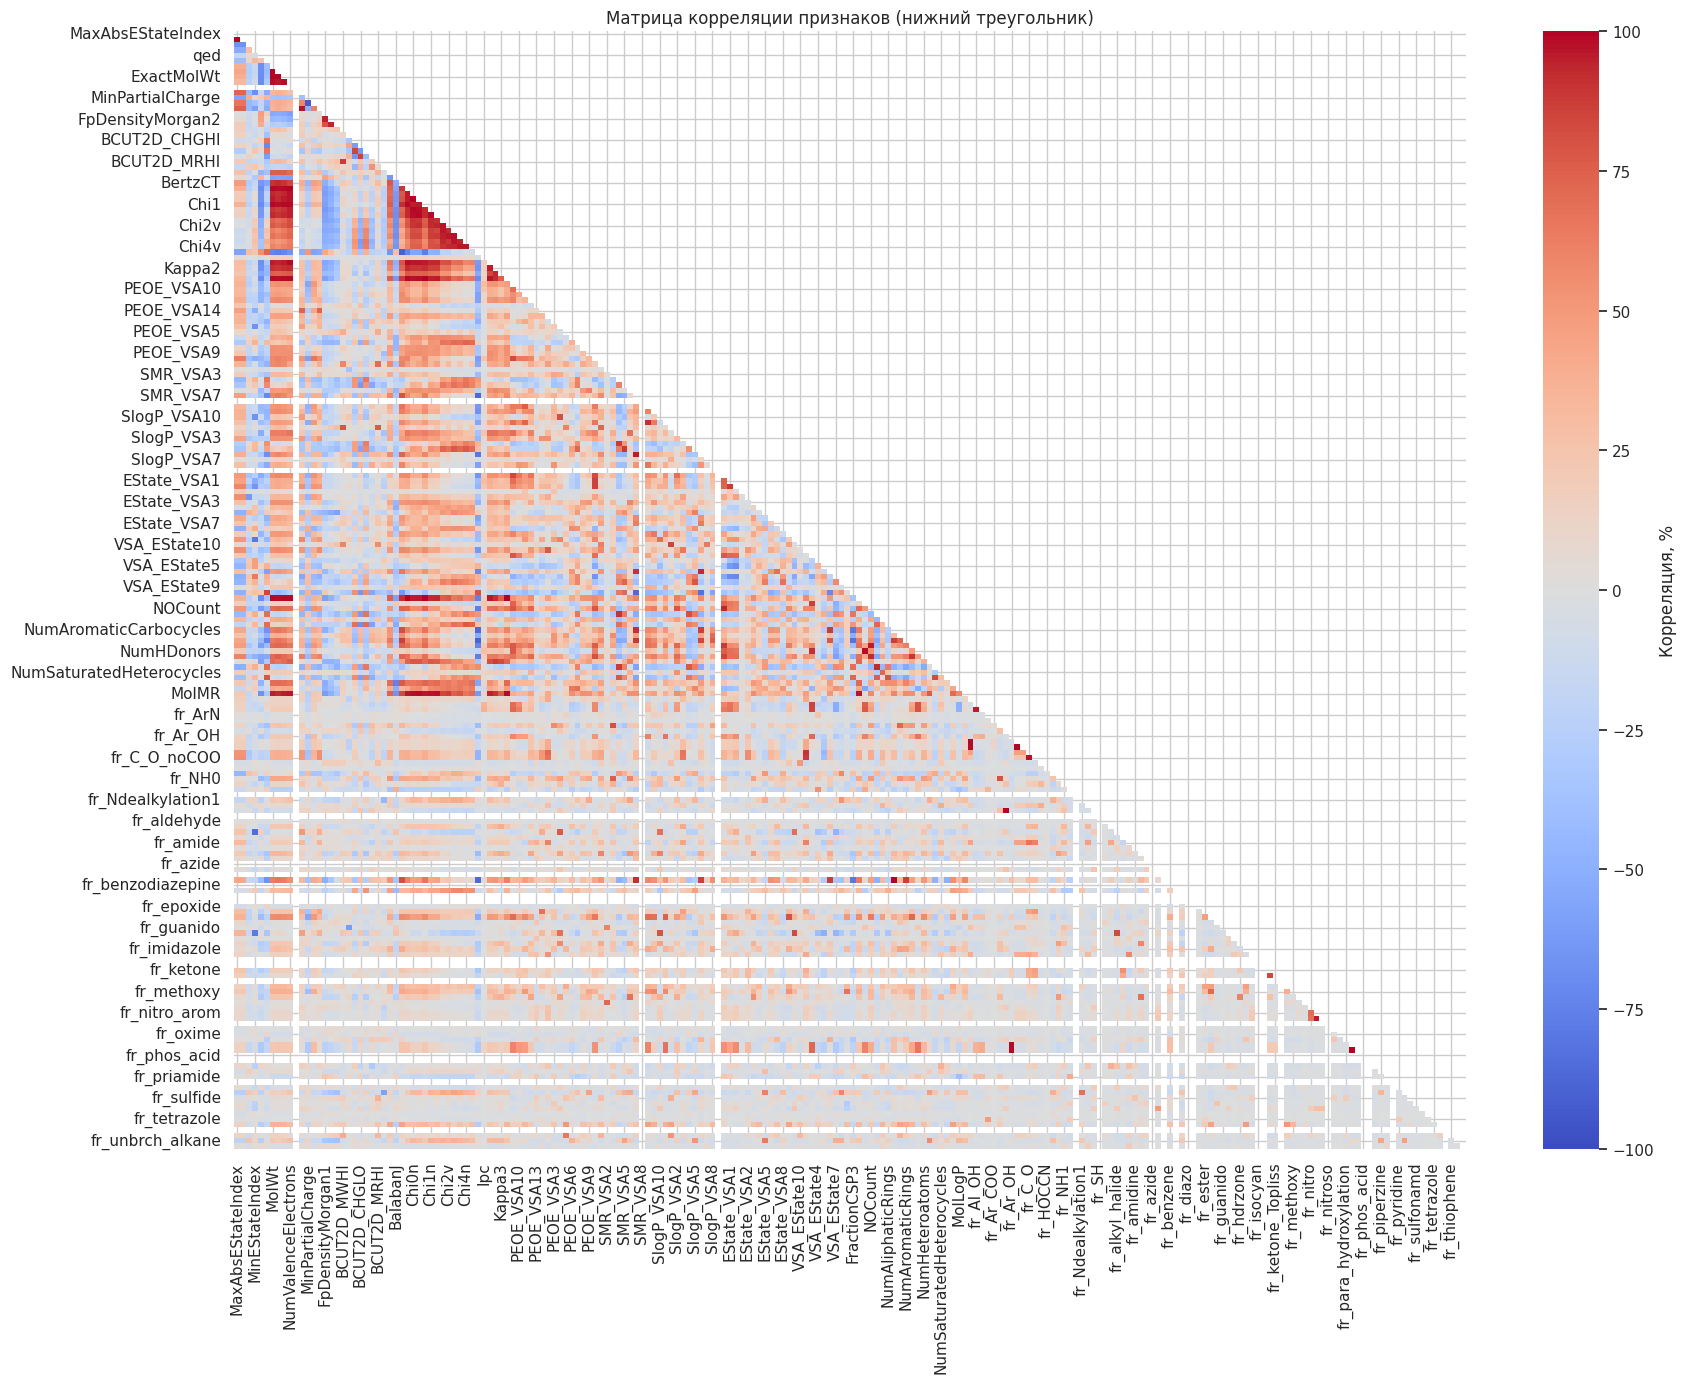

In [93]:
X = df_clear[[col for col in df_clear.columns
              if col not in TARGET_COLS and not col.startswith('y_')]].copy()

print(f'Признаков: {X.shape[1]}')

corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr * 100,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-100, vmax=100,
    annot=False,
    linewidths=0,
    cbar_kws={'label': 'Корреляция, %'}
)
plt.title('Матрица корреляции признаков (нижний треугольник)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [94]:
corr_abs = X.corr().abs()

upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

corr_pairs = (
    upper
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "abs_correlation"]

corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False)

display(corr_pairs.head(30))

for threshold in [0.7, 0.8, 0.9, 0.95]:
    n_pairs = (corr_pairs["abs_correlation"] >= threshold).sum()
    print(f"Пар признаков с абсолютной корреляцией >= {threshold}: {n_pairs}")

,feature_1,feature_2,abs_correlation
23679,NumAromaticCarbocycles,fr_benzene,1.000000
27656,fr_Ar_NH,fr_Nhpyrrole,1.000000
28064,fr_COO,fr_COO2,1.000000
40091,fr_phenol,fr_phenol_noOrthoHbond,1.000000
1,MaxAbsEStateIndex,MaxEStateIndex,1.000000
1268,MolWt,ExactMolWt,0.999999
6826,Chi1,HeavyAtomCount,0.998733
1267,MolWt,HeavyAtomMolWt,0.996888
1478,HeavyAtomMolWt,ExactMolWt,0.996857
6196,Chi0,HeavyAtomCount,0.995964


Пар признаков с абсолютной корреляцией >= 0.7: 428
Пар признаков с абсолютной корреляцией >= 0.8: 243
Пар признаков с абсолютной корреляцией >= 0.9: 154
Пар признаков с абсолютной корреляцией >= 0.95: 94


### Корреляция признаков с целевыми переменными

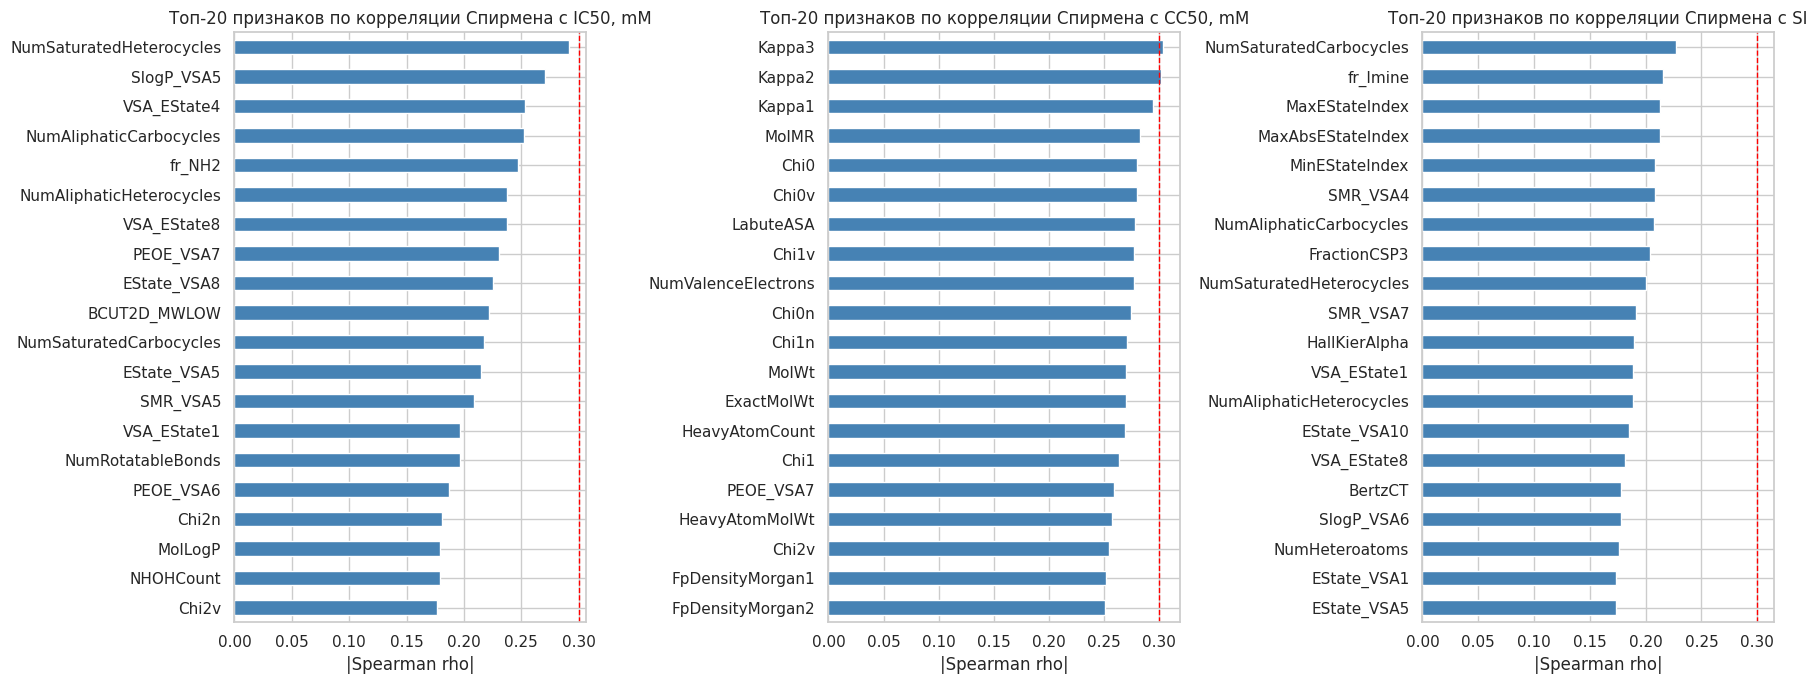

In [95]:
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, target in zip(axes, TARGET_COLS):
    corr_with_target = (
        X.corrwith(df_clear[target], method="spearman")
        .abs()
        .sort_values(ascending=False)
        .head(TOP_N)
    )

    corr_with_target.sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"Топ-{TOP_N} признаков по корреляции Спирмена с {target}")
    ax.set_xlabel("|Spearman rho|")
    ax.axvline(0.3, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

## Выводы

### Данные

Пропуски обнаружены в 3 строках (0.3% выборки), дубликаты обнаружены в 32 строках (3.2% выборки) -- удалены без потери информативности; итоговый объём выборки составил 966 наблюдений.


### Целевые переменные

- IC50: медиана 45.22 мМ, асимметрия 3.80 -- выраженный правый хвост, log1p-преобразование делает распределение почти симметричным.
- CC50: медиана 422.16 мМ, асимметрия 2.01 -- умеренно выраженная правосторонняя асимметрия, log1p-преобразование также снижает скошенность.
- SI: медиана 3.91, асимметрия 17.67, max 15620.6 -- экстремально скошенное распределение из-за природы SI = CC50 / IC50; для регрессии по SI log1p-преобразование особенно важно.
- Для задач классификации по медиане классы практически сбалансированы.
- Для задачи SI > 8 доля положительного класса составляет 35.4% -- есть умеренный дисбаланс, поэтому при моделировании нужно использовать не только accuracy, но и F1, ROC-AUC и PR-AUC.

### Признаковое пространство

В исходном пространстве (210 признаков) выявлена высокая мультиколлинеарность: пар с корреляцией >= 0.7 -- 428, >= 0.9 -- 154. Топ-признаки по корреляции Спирмена с таргетами могут использоваться при интерпретации результатов моделей.

### Общие выводы

Для регрессионных моделей IC50, CC50 и SI целесообразно рассматривать log1p-преобразование целевых переменных, так как исходные распределения имеют сильную правостороннюю асимметрию. В то время как для классификационных задач по медиане, ожидается почти сбалансированная постановка, в задаче SI > 8 имеется умеренный дисбаланс классов. Поэтому при моделировании необходимо использовать не только accuracy, но и F1, ROC-AUC и PR-AUC. В признаковом пространстве присутствуют группы сильно коррелирующих RDKit-дескрипторов. Поэтому удаление константных признаков, фильтрация по высокой корреляции и VIF-редукция являются необходимыми шагами. Так как SI является производной величиной от IC50 и CC50, модели для SI могут быть более нестабильными и чувствительными к экстремальным значениям.

Выходные данные: SF_ML_data_clear.pkl (результат EDA).